# Modelado Avanzado y Tuning de Hiperparámetros — Scoring de Intención de Compra

**Objetivo:** extender la comparativa de modelos de `modeling_mvp.ipynb` (Sprint 1) con
algoritmos ensemble adicionales — LightGBM y CatBoost, sumados a XGBoost — optimizar sus
hiperparámetros con Optuna, y evaluar dos técnicas adicionales sobre el modelo ganador:
re-muestreo (SMOTE vs. `class_weight`) y calibración de probabilidades
(`CalibratedClassifierCV`).

El criterio de optimización/selección es **PR-AUC (`average_precision`)**, no F1: PR-AUC no
depende de un umbral de decisión, mientras que F1 asume el umbral 0.5 por defecto de
scikit-learn, que no es el que usa el motor de recomendación (`src/recommender.py` decide con
umbrales de negocio 0.7/0.3). Es además el criterio que ya usó el equipo para elegir el modelo
final en Sprint 1 (ROC-AUC/PR-AUC).

`modeling_mvp.ipynb` es un entregable de Sprint 1 ya aprobado y no se modifica — este notebook
es un artefacto nuevo de Sprint 2.

Pasos:

1. Cargar los artefactos de `feature_enginering.ipynb` (mismo split/preprocesador que usó Sprint 1).
2. Reentrenar Random Forest y XGBoost (misma configuración que Sprint 1) como referencia directa.
3. Entrenar LightGBM y CatBoost sin tunear, con el mismo manejo de desbalance por pesos de clase.
4. Tunear XGBoost, LightGBM y CatBoost con Optuna (Stratified 3-Fold CV sobre train, optimizando PR-AUC).
5. Elegir el mejor candidato hasta ese punto.
6. Re-muestreo: comparar SMOTE contra `class_weight` para ese modelo (Sprint 1 solo probó esto con Regresión Logística).
7. Calibración de probabilidades: evaluar si `CalibratedClassifierCV` corrige el desajuste entre probabilidad predicha y tasa real de compra.
8. Comparativa final entre **todos** los candidatos evaluados (tuning + remuestreo + calibración) y selección del ganador definitivo.
9. Verificar que el motor de recomendación (`asignar_accion`/`resumen_acciones`) sigue siendo coherente con el ganador definitivo.
10. Persistir el nuevo modelo final (y sus hiperparámetros) solo si supera al Random Forest de Sprint 1.

## 1. Configuración y carga de artefactos

In [1]:
import sys
import time
from pathlib import Path

import joblib
import numpy as np
import optuna
from catboost import CatBoostClassifier
from imblearn.over_sampling import SMOTE
from lightgbm import LGBMClassifier
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import average_precision_score, brier_score_loss
from sklearn.model_selection import StratifiedKFold
from xgboost import XGBClassifier

import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.metrics import comparar_modelos, evaluar_modelo
from src.recommender import asignar_accion, resumen_acciones

optuna.logging.set_verbosity(optuna.logging.WARNING)

CARPETA_MODELOS = PROJECT_ROOT / "data" / "models"
split = joblib.load(CARPETA_MODELOS / "train_test_split.joblib")

X_train, X_test = split["X_train"], split["X_test"]
y_train, y_test = split["y_train"], split["y_test"]

print(f"X_train: {X_train.shape}, y_train: {y_train.shape}, balance: {y_train.mean():.4f}")
print(f"X_test: {X_test.shape}, y_test: {y_test.shape}, balance: {y_test.mean():.4f}")

/home/juanma/HENRRY/PROYECTO_FINAL/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


X_train: (9764, 78), y_train: (9764,), balance: 0.1563
X_test: (2441, 78), y_test: (2441,), balance: 0.1565


`X_train`/`X_test` son las mismas matrices ya codificadas y escaladas que usó
`modeling_mvp.ipynb` (`preprocessor`, ajustado solo con train en `feature_enginering.ipynb`).

## 2. Referencia Sprint 1: Random Forest y XGBoost

Se reentrenan con exactamente la misma configuración que en `modeling_mvp.ipynb`, para
tener el punto de comparación directo en la misma tabla que los modelos nuevos.

In [2]:
resultados = {}
modelos = {}

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f"scale_pos_weight (razón negativos/positivos en train): {scale_pos_weight:.4f}")

rf = RandomForestClassifier(
    n_estimators=300, class_weight="balanced", random_state=42, n_jobs=-1
)
rf.fit(X_train, y_train)
resultados["random_forest"] = evaluar_modelo(
    y_test, rf.predict(X_test), rf.predict_proba(X_test)[:, 1]
)
modelos["random_forest"] = rf
resultados["random_forest"]

scale_pos_weight (razón negativos/positivos en train): 5.3984


{'precision': 0.6577669902912622,
 'recall': 0.7094240837696335,
 'f1': 0.6826196473551638,
 'roc_auc': 0.924264943333952,
 'average_precision': 0.7226931082367187}

In [3]:
xgb_base = XGBClassifier(
    n_estimators=300,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric="logloss",
)
xgb_base.fit(X_train, y_train)
resultados["xgboost"] = evaluar_modelo(
    y_test, xgb_base.predict(X_test), xgb_base.predict_proba(X_test)[:, 1]
)
modelos["xgboost"] = xgb_base
resultados["xgboost"]

{'precision': 0.6458852867830424,
 'recall': 0.6780104712041884,
 'f1': 0.6615581098339719,
 'roc_auc': 0.9220641596464507,
 'average_precision': 0.7170867562321463}

## 3. Modelos ensemble adicionales (baseline, sin tuning)

Mismo criterio de manejo del desbalance (~85/15) que ya usa el proyecto, adaptado a cada
librería: `class_weight="balanced"` en LightGBM (equivalente a scikit-learn) y
`auto_class_weights="Balanced"` en CatBoost (su forma nativa de ponderar la clase minoritaria).

In [4]:
lgbm_base = LGBMClassifier(class_weight="balanced", random_state=42, verbose=-1)
lgbm_base.fit(X_train, y_train)
resultados["lightgbm"] = evaluar_modelo(
    y_test, lgbm_base.predict(X_test), lgbm_base.predict_proba(X_test)[:, 1]
)
modelos["lightgbm"] = lgbm_base
resultados["lightgbm"]

{'precision': 0.5722326454033771,
 'recall': 0.7984293193717278,
 'f1': 0.6666666666666666,
 'roc_auc': 0.9318697888722477,
 'average_precision': 0.7474171703056453}

In [5]:
cat_base = CatBoostClassifier(auto_class_weights="Balanced", random_state=42, verbose=False)
cat_base.fit(X_train, y_train)
resultados["catboost"] = evaluar_modelo(
    y_test, cat_base.predict(X_test), cat_base.predict_proba(X_test)[:, 1]
)
modelos["catboost"] = cat_base
resultados["catboost"]

{'precision': 0.5733333333333334,
 'recall': 0.7879581151832461,
 'f1': 0.6637265711135611,
 'roc_auc': 0.9317464636165067,
 'average_precision': 0.7379321911450423}

In [6]:
print("Comparativa baseline (antes de tuning), ordenada por PR-AUC:")
comparar_modelos(resultados, criterio="average_precision")

Comparativa baseline (antes de tuning), ordenada por PR-AUC:


,precision,recall,f1,roc_auc,average_precision
lightgbm,0.572233,0.798429,0.666667,0.931870,0.747417
catboost,0.573333,0.787958,0.663727,0.931746,0.737932
random_forest,0.657767,0.709424,0.682620,0.924265,0.722693
xgboost,0.645885,0.678010,0.661558,0.922064,0.717087


## 4. Tuning de hiperparámetros con Optuna

Un `study` de Optuna por modelo (XGBoost, LightGBM, CatBoost), maximizando el promedio de
`average_precision` (PR-AUC) en Stratified 3-Fold CV **sobre train únicamente** — el test set
queda fuera de la búsqueda y solo se usa al final para evaluar el modelo ya elegido, igual que en
el resto del proyecto. Cada estudio corre hasta 30 trials o 4 minutos (lo que ocurra primero),
para mantener el tiempo total acotado. El manejo del desbalance de clases (`scale_pos_weight` /
`class_weight="balanced"` / `auto_class_weights="Balanced"`) se deja fijo en cada modelo — igual
que en la sección anterior — y Optuna solo busca sobre los hiperparámetros de complejidad/regularización
del árbol. (La Sección 6 retoma la pregunta de remuestreo vs. pesos de clase para el ganador.)

In [7]:
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
N_TRIALS = 30
TIMEOUT_S = 240


def cv_average_precision(model_cls, params):
    scores = []
    for train_idx, val_idx in cv.split(X_train, y_train):
        modelo = model_cls(**params)
        y_fit = y_train.iloc[train_idx] if hasattr(y_train, "iloc") else y_train[train_idx]
        modelo.fit(X_train[train_idx], y_fit)
        y_val = y_train.iloc[val_idx] if hasattr(y_train, "iloc") else y_train[val_idx]
        prob = modelo.predict_proba(X_train[val_idx])[:, 1]
        scores.append(average_precision_score(y_val, prob))
    return float(np.mean(scores))

In [8]:
def objective_xgb(trial):
    params = dict(
        n_estimators=trial.suggest_int("n_estimators", 100, 500),
        max_depth=trial.suggest_int("max_depth", 3, 10),
        learning_rate=trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        subsample=trial.suggest_float("subsample", 0.5, 1.0),
        colsample_bytree=trial.suggest_float("colsample_bytree", 0.5, 1.0),
        reg_alpha=trial.suggest_float("reg_alpha", 1e-8, 10.0, log=True),
        reg_lambda=trial.suggest_float("reg_lambda", 1e-8, 10.0, log=True),
        scale_pos_weight=scale_pos_weight,
        random_state=42,
        eval_metric="logloss",
        n_jobs=-1,
    )
    return cv_average_precision(XGBClassifier, params)


def objective_lgbm(trial):
    params = dict(
        n_estimators=trial.suggest_int("n_estimators", 100, 500),
        num_leaves=trial.suggest_int("num_leaves", 15, 255),
        max_depth=trial.suggest_int("max_depth", 3, 12),
        learning_rate=trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        subsample=trial.suggest_float("subsample", 0.5, 1.0),
        colsample_bytree=trial.suggest_float("colsample_bytree", 0.5, 1.0),
        reg_alpha=trial.suggest_float("reg_alpha", 1e-8, 10.0, log=True),
        reg_lambda=trial.suggest_float("reg_lambda", 1e-8, 10.0, log=True),
        min_child_samples=trial.suggest_int("min_child_samples", 5, 100),
        class_weight="balanced",
        random_state=42,
        verbose=-1,
        n_jobs=-1,
    )
    return cv_average_precision(LGBMClassifier, params)


def objective_cat(trial):
    params = dict(
        iterations=trial.suggest_int("iterations", 100, 500),
        depth=trial.suggest_int("depth", 3, 10),
        learning_rate=trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        l2_leaf_reg=trial.suggest_float("l2_leaf_reg", 1.0, 10.0, log=True),
        auto_class_weights="Balanced",
        random_state=42,
        verbose=False,
        thread_count=-1,
    )
    return cv_average_precision(CatBoostClassifier, params)

In [9]:
tuning_specs = {
    "xgboost_tuned": (
        objective_xgb, XGBClassifier,
        {"scale_pos_weight": scale_pos_weight, "random_state": 42, "eval_metric": "logloss", "n_jobs": -1},
    ),
    "lightgbm_tuned": (
        objective_lgbm, LGBMClassifier,
        {"class_weight": "balanced", "random_state": 42, "verbose": -1, "n_jobs": -1},
    ),
    "catboost_tuned": (
        objective_cat, CatBoostClassifier,
        {"auto_class_weights": "Balanced", "random_state": 42, "verbose": False, "thread_count": -1},
    ),
}

# Clave de cada tuning_spec que corresponde al manejo del desbalance de clases,
# para poder quitarla puntualmente en la Sección 6 (remuestreo con SMOTE).
CLAVE_BALANCEO = {
    "xgboost_tuned": "scale_pos_weight",
    "lightgbm_tuned": "class_weight",
    "catboost_tuned": "auto_class_weights",
}

mejores_hiperparametros = {}
estudios = {}

for nombre, (objective, model_cls, params_fijos) in tuning_specs.items():
    t0 = time.time()
    study = optuna.create_study(direction="maximize", study_name=nombre)
    study.optimize(objective, n_trials=N_TRIALS, timeout=TIMEOUT_S, show_progress_bar=False)
    estudios[nombre] = study

    mejores_params = {**study.best_params, **params_fijos}
    modelo_tuneado = model_cls(**mejores_params)
    modelo_tuneado.fit(X_train, y_train)

    resultados[nombre] = evaluar_modelo(
        y_test, modelo_tuneado.predict(X_test), modelo_tuneado.predict_proba(X_test)[:, 1]
    )
    modelos[nombre] = modelo_tuneado
    mejores_hiperparametros[nombre] = study.best_params

    print(
        f"{nombre}: {time.time()-t0:.1f}s, {len(study.trials)} trials, "
        f"mejor PR-AUC en CV={study.best_value:.4f}, PR-AUC en test={resultados[nombre]['average_precision']:.4f}"
    )

xgboost_tuned: 63.8s, 30 trials, mejor PR-AUC en CV=0.7530, PR-AUC en test=0.7532


lightgbm_tuned: 38.4s, 30 trials, mejor PR-AUC en CV=0.7504, PR-AUC en test=0.7592


catboost_tuned: 198.2s, 30 trials, mejor PR-AUC en CV=0.7532, PR-AUC en test=0.7489


## 5. Mejor candidato hasta ahora

In [10]:
tabla_interina = comparar_modelos(resultados, criterio="average_precision")
tabla_interina

,precision,recall,f1,roc_auc,average_precision
lightgbm_tuned,0.535831,0.861257,0.660643,0.938915,0.759177
xgboost_tuned,0.550918,0.863874,0.672783,0.938157,0.753157
catboost_tuned,0.549915,0.850785,0.668037,0.936767,0.748859
lightgbm,0.572233,0.798429,0.666667,0.931870,0.747417
catboost,0.573333,0.787958,0.663727,0.931746,0.737932
random_forest,0.657767,0.709424,0.682620,0.924265,0.722693
xgboost,0.645885,0.678010,0.661558,0.922064,0.717087


In [11]:
mejor_modelo_nombre = tabla_interina.index[0]
mejor_modelo = modelos[mejor_modelo_nombre]
print(f"Mejor candidato hasta ahora (tuning): {mejor_modelo_nombre}")
print(tabla_interina.loc[mejor_modelo_nombre])

Mejor candidato hasta ahora (tuning): lightgbm_tuned
precision            0.535831
recall               0.861257
f1                   0.660643
roc_auc              0.938915
average_precision    0.759177
Name: lightgbm_tuned, dtype: float64


Las Secciones 6 y 7 evalúan dos técnicas adicionales sobre este candidato, antes de la
comparativa final (Sección 8) que decide el modelo que efectivamente se persiste.

## 6. Re-muestreo: SMOTE vs. `class_weight`

Sprint 1 (`modeling_mvp.ipynb`) ya comparó SMOTE contra `class_weight="balanced"`, pero
solo para la Regresión Logística. Acá se extiende la misma pregunta al modelo ensemble ganador
de esta ronda, manteniendo los mismos hiperparámetros de complejidad ya encontrados por Optuna
y cambiando únicamente la estrategia de balanceo: `class_weight`/`scale_pos_weight`/
`auto_class_weights` (penaliza errores en la clase minoritaria) vs. SMOTE (sobresamplea la
clase minoritaria por interpolación, aplicado **solo sobre train**, igual que en Sprint 1).

In [12]:
if mejor_modelo_nombre in mejores_hiperparametros:
    _, modelo_cls_ganador, params_fijos_ganador = tuning_specs[mejor_modelo_nombre]

    params_smote = {**params_fijos_ganador}
    params_smote.pop(CLAVE_BALANCEO[mejor_modelo_nombre], None)
    params_smote.update(mejores_hiperparametros[mejor_modelo_nombre])

    X_train_smote, y_train_smote = SMOTE(random_state=42).fit_resample(X_train, y_train)
    print(f"Train original: {X_train.shape[0]} filas, balance: {y_train.mean():.4f}")
    print(f"Train con SMOTE: {X_train_smote.shape[0]} filas, balance: {y_train_smote.mean():.4f}")

    modelo_smote = modelo_cls_ganador(**params_smote)
    modelo_smote.fit(X_train_smote, y_train_smote)

    nombre_smote = f"{mejor_modelo_nombre.replace('_tuned', '')}_smote"
    resultados[nombre_smote] = evaluar_modelo(
        y_test, modelo_smote.predict(X_test), modelo_smote.predict_proba(X_test)[:, 1]
    )
    modelos[nombre_smote] = modelo_smote
    print(f"\n{nombre_smote}: {resultados[nombre_smote]}")
else:
    nombre_smote = None
    print("El candidato ganador no tiene hiperparámetros tuneados registrados; se omite esta sección.")

Train original: 9764 filas, balance: 0.1563
Train con SMOTE: 16476 filas, balance: 0.5000



lightgbm_smote: {'precision': 0.6191489361702127, 'recall': 0.7617801047120419, 'f1': 0.6830985915492958, 'roc_auc': 0.9368682759129248, 'average_precision': 0.7445057321131643}


In [13]:
if nombre_smote:
    comparar_modelos(
        {mejor_modelo_nombre: resultados[mejor_modelo_nombre], nombre_smote: resultados[nombre_smote]},
        criterio="average_precision",
    )

Mismos hiperparámetros de complejidad en ambos casos — la única diferencia es la estrategia
de balanceo. El resultado indica cuál conviene para este modelo y este dataset.

## 7. Calibración de probabilidades (`CalibratedClassifierCV`)

El motor de recomendación (`asignar_accion`) decide con **umbrales absolutos** de
probabilidad (0,7/0,3), no con un ranking. Si el modelo está mal calibrado, "probabilidad > 70%"
no significa necesariamente "70% de esas sesiones terminan en compra" — que es justo lo que
auditó `modeling_mvp.ipynb` con `resumen_acciones`: el segmento `cross_selling` (prob. > 70%)
tuvo una tasa real de compra bastante por debajo de ese umbral. Se evalúa si
`CalibratedClassifierCV` (Platt scaling / isotónica) corrige ese desajuste, y si lo hace sin
perder poder de ranking (PR-AUC).

In [14]:
resultados_calibracion = {}


def evaluar_calibracion(nombre, modelo):
    y_prob = modelo.predict_proba(X_test)[:, 1]
    metricas = evaluar_modelo(y_test, modelo.predict(X_test), y_prob)
    metricas["brier_score"] = brier_score_loss(y_test, y_prob)
    resultados_calibracion[nombre] = metricas
    return metricas


evaluar_calibracion("sin_calibrar", mejor_modelo)

modelos_calibrados = {}
if mejor_modelo_nombre in tuning_specs:
    _, modelo_cls_ganador, params_fijos_ganador = tuning_specs[mejor_modelo_nombre]
    base_params = {**params_fijos_ganador, **mejores_hiperparametros[mejor_modelo_nombre]}

    for metodo in ("sigmoid", "isotonic"):
        t0 = time.time()
        calibrado = CalibratedClassifierCV(
            estimator=modelo_cls_ganador(**base_params), method=metodo, cv=3
        )
        calibrado.fit(X_train, y_train)
        nombre_cal = f"calibrado_{metodo}"
        evaluar_calibracion(nombre_cal, calibrado)

        nombre_completo = f"{mejor_modelo_nombre.replace('_tuned', '')}_{nombre_cal}"
        modelos_calibrados[nombre_completo] = calibrado
        modelos[nombre_completo] = calibrado
        resultados[nombre_completo] = resultados_calibracion[nombre_cal]
        print(f"{nombre_cal}: {time.time()-t0:.1f}s -> {resultados_calibracion[nombre_cal]}")

comparar_modelos(resultados_calibracion, criterio="average_precision")

calibrado_sigmoid: 1.2s -> {'precision': 0.7159090909090909, 'recall': 0.6596858638743456, 'f1': 0.6866485013623979, 'roc_auc': 0.9394066148107276, 'average_precision': 0.7617381672068503, 'brier_score': 0.06728812512156924}


calibrado_isotonic: 0.8s -> {'precision': 0.7272727272727273, 'recall': 0.6492146596858639, 'f1': 0.686030428769018, 'roc_auc': 0.9393741942538059, 'average_precision': 0.7580907861460029, 'brier_score': 0.0670745680776182}


,precision,recall,f1,roc_auc,average_precision,brier_score
calibrado_sigmoid,0.715909,0.659686,0.686649,0.939407,0.761738,0.067288
sin_calibrar,0.535831,0.861257,0.660643,0.938915,0.759177,0.102442
calibrado_isotonic,0.727273,0.649215,0.686030,0.939374,0.758091,0.067075


**Curva de calibración (reliability diagram):** para cada bin de probabilidad predicha, se
compara contra la fracción real de compras observadas en ese bin. La diagonal punteada es la
calibración perfecta.

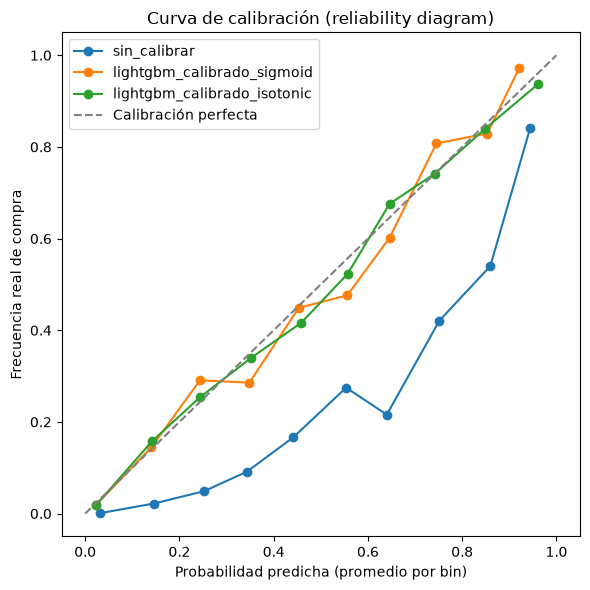

In [15]:
plt.figure(figsize=(6, 6))
candidatos_calibracion = [("sin_calibrar", mejor_modelo)] + list(modelos_calibrados.items())
for nombre, modelo_cal in candidatos_calibracion:
    prob_true, prob_pred = calibration_curve(y_test, modelo_cal.predict_proba(X_test)[:, 1], n_bins=10)
    plt.plot(prob_pred, prob_true, marker="o", label=nombre)
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Calibración perfecta")
plt.xlabel("Probabilidad predicha (promedio por bin)")
plt.ylabel("Frecuencia real de compra")
plt.title("Curva de calibración (reliability diagram)")
plt.legend()
plt.tight_layout()
plt.show()

## 8. Comparativa final y selección del modelo definitivo

Se compara **todo** lo evaluado hasta acá: los 7 candidatos de las Secciones 2-4 (referencia
Sprint 1, ensembles baseline, tuning) más la variante de remuestreo (Sección 6) y las variantes
calibradas (Sección 7). Se elige por PR-AUC, igual que en todo el notebook.

In [16]:
tabla_final = comparar_modelos(resultados, criterio="average_precision")
tabla_final

,precision,recall,f1,roc_auc,average_precision,brier_score
lightgbm_calibrado_sigmoid,0.715909,0.659686,0.686649,0.939407,0.761738,0.067288
lightgbm_tuned,0.535831,0.861257,0.660643,0.938915,0.759177,NaN
lightgbm_calibrado_isotonic,0.727273,0.649215,0.686030,0.939374,0.758091,0.067075
xgboost_tuned,0.550918,0.863874,0.672783,0.938157,0.753157,NaN
catboost_tuned,0.549915,0.850785,0.668037,0.936767,0.748859,NaN
lightgbm,0.572233,0.798429,0.666667,0.931870,0.747417,NaN
lightgbm_smote,0.619149,0.761780,0.683099,0.936868,0.744506,NaN
catboost,0.573333,0.787958,0.663727,0.931746,0.737932,NaN
random_forest,0.657767,0.709424,0.682620,0.924265,0.722693,NaN
xgboost,0.645885,0.678010,0.661558,0.922064,0.717087,NaN


In [17]:
ganador_nombre = tabla_final.index[0]
ganador_modelo = modelos[ganador_nombre]
print(f"Modelo ganador definitivo: {ganador_nombre}")
print(tabla_final.loc[ganador_nombre])

Modelo ganador definitivo: lightgbm_calibrado_sigmoid
precision            0.715909
recall               0.659686
f1                   0.686649
roc_auc              0.939407
average_precision    0.761738
brier_score          0.067288
Name: lightgbm_calibrado_sigmoid, dtype: float64


## 8.1 Registro de experimentos en MLflow

Se registra cada candidato evaluado hasta acá (Secciones 2-7) como un run de MLflow —
hiperparámetros (para los que tienen tuning de Optuna), métricas de clasificación
(`evaluar_modelo`) y de ranking (`Precision@K`/`Recall@K` de `src.metrics.evaluar_ranking`, al
10% y 20% de las sesiones con mayor probabilidad de compra). El modelo ganador definitivo
además queda versionado como artefacto de MLflow (`mlflow.sklearn.log_model`), independientemente
de si reemplaza o no a `modelo_final.joblib` en la Sección 10.

Esto resuelve, para cualquier corrida futura del notebook, la comparación sistemática entre
versiones que hoy solo vive en la salida impresa de `tabla_final`.

In [18]:
import mlflow
import mlflow.sklearn

from src.metrics import evaluar_ranking

# MLflow 3.x dejó en mantenimiento el backend de filesystem plano ("file:./mlruns");
# sqlite es la alternativa liviana sin levantar un server aparte.
RUTA_MLFLOW_DB = PROJECT_ROOT / "mlflow.db"
mlflow.set_tracking_uri(f"sqlite:///{RUTA_MLFLOW_DB}")
mlflow.set_experiment("scoring_intencion_compra")

K_PCT_LOGUEADOS = [0.10, 0.20]

for nombre_modelo, metricas in resultados.items():
    modelo_obj = modelos[nombre_modelo]
    y_prob_modelo = modelo_obj.predict_proba(X_test)[:, 1]
    ranking = evaluar_ranking(y_test, y_prob_modelo, k_pct=K_PCT_LOGUEADOS)

    with mlflow.start_run(run_name=nombre_modelo):
        mlflow.set_tags({"sprint": "2", "es_ganador": str(nombre_modelo == ganador_nombre)})
        mlflow.log_params(mejores_hiperparametros.get(nombre_modelo, {}))
        mlflow.log_metrics(metricas)
        for k_pct, fila in ranking.iterrows():
            etiqueta = int(k_pct * 100)
            mlflow.log_metric(f"precision_at_{etiqueta}pct", fila["precision_at_k"])
            mlflow.log_metric(f"recall_at_{etiqueta}pct", fila["recall_at_k"])
        if nombre_modelo == ganador_nombre:
            # pickle/cloudpickle en vez del default 'skops': mismo formato de serialización
            # que ya usa el resto del proyecto (joblib) para este modelo (LightGBM calibrado).
            mlflow.sklearn.log_model(modelo_obj, name="modelo", serialization_format="cloudpickle")

print(f"{len(resultados)} runs registrados en el experimento 'scoring_intencion_compra'.")
print(f"Ver con: mlflow ui --backend-store-uri sqlite:///{RUTA_MLFLOW_DB}")

2026/08/17 09:37:10 INFO mlflow.store.db.utils: Creating initial MLflow database tables...


2026/08/17 09:37:10 INFO mlflow.store.db.utils: Updating database tables


2026/08/17 09:37:11 INFO mlflow.tracking.fluent: Experiment with name 'scoring_intencion_compra' does not exist. Creating a new experiment.


2026/08/17 09:37:12 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


10 runs registrados en el experimento 'scoring_intencion_compra'.
Ver con: mlflow ui --backend-store-uri sqlite:////home/juanma/HENRRY/PROYECTO_FINAL/Proyecto-Final-Henry/mlflow.db


## 9. Verificación de negocio: motor de recomendación

Se corrobora, con el ganador definitivo, que `cross_selling` sigue concentrando una tasa de
compra real claramente mayor que `retencion` antes de reemplazar el modelo que sirve el motor de
recomendación.

In [19]:
y_prob_final = ganador_modelo.predict_proba(X_test)[:, 1]
acciones = asignar_accion(y_prob_final)
acciones.value_counts()

accion
retencion        1984
sin_accion        261
cross_selling     196
Name: count, dtype: int64

In [20]:
resumen_acciones(acciones, y_test)

,n_sesiones,tasa_compra_real,pct_del_total
accion,,,
retencion,1984,0.046371,81.28
sin_accion,261,0.475096,10.69
cross_selling,196,0.846939,8.03


## 10. Persistencia del modelo final

Solo se reemplaza `data/models/modelo_final.joblib` (el que sirve el motor de recomendación)
si el ganador definitivo supera en PR-AUC al Random Forest de Sprint 1. Si ningún candidato lo
supera, se deja constancia explícita y el Random Forest se mantiene como modelo final.

In [21]:
RUTA_MODELO_FINAL = CARPETA_MODELOS / "modelo_final.joblib"
RUTA_HIPERPARAMETROS = CARPETA_MODELOS / "mejores_hiperparametros.json"

pr_auc_actual = resultados["random_forest"]["average_precision"]
pr_auc_candidato = resultados[ganador_nombre]["average_precision"]

print(f"PR-AUC modelo final actual (Random Forest, Sprint 1): {pr_auc_actual:.4f}")
print(f"PR-AUC mejor candidato de esta ronda ({ganador_nombre}): {pr_auc_candidato:.4f}")

if ganador_nombre != "random_forest" and pr_auc_candidato > pr_auc_actual:
    joblib.dump(ganador_modelo, RUTA_MODELO_FINAL)
    print(f"\nNuevo modelo final: {ganador_nombre} (guardado en {RUTA_MODELO_FINAL})")

    import json

    payload = {
        "modelo": ganador_nombre,
        "metricas_test": resultados[ganador_nombre],
        "hiperparametros_base": mejores_hiperparametros.get(mejor_modelo_nombre, {}),
    }
    with open(RUTA_HIPERPARAMETROS, "w") as f:
        json.dump(payload, f, indent=2, default=float)
    print(f"Hiperparámetros / metadatos del ganador guardados en {RUTA_HIPERPARAMETROS}")
else:
    print("\nNingún candidato superó al Random Forest de Sprint 1: se mantiene como modelo final.")

PR-AUC modelo final actual (Random Forest, Sprint 1): 0.7227
PR-AUC mejor candidato de esta ronda (lightgbm_calibrado_sigmoid): 0.7617

Nuevo modelo final: lightgbm_calibrado_sigmoid (guardado en /home/juanma/HENRRY/PROYECTO_FINAL/Proyecto-Final-Henry/data/models/modelo_final.joblib)
Hiperparámetros / metadatos del ganador guardados en /home/juanma/HENRRY/PROYECTO_FINAL/Proyecto-Final-Henry/data/models/mejores_hiperparametros.json


## 11. Conclusiones

- LightGBM y CatBoost se suman a la comparativa de Sprint 1 (Random Forest, XGBoost) bajo el
  mismo manejo de desbalance por pesos de clase, sin tuning.
- El tuning con Optuna busca hiperparámetros de complejidad/regularización por Stratified
  3-Fold CV sobre train, optimizando PR-AUC — sin tocar el test set hasta la evaluación final.
- **Re-muestreo vs. pesos de clase:** Sprint 1 solo había comparado esto para Regresión
  Logística; este notebook extiende la comparación al modelo ensemble ganador, con los mismos
  hiperparámetros de complejidad y cambiando solo la estrategia de balanceo.
- **Calibración de probabilidades:** los modelos ensemble sin calibrar tienden a ser
  overconfident (la probabilidad predicha se aleja de la tasa real de compra, especialmente en
  el rango medio) — relevante acá porque el motor de recomendación decide con umbrales
  absolutos (0,7/0,3), no con un ranking. `CalibratedClassifierCV` (sigmoid/isotónica) se evalúa
  con Brier score y curva de calibración, además de PR-AUC.
- El modelo final se decide por PR-AUC (no F1) entre **todos** los candidatos evaluados
  (tuning + remuestreo + calibración), porque el motor de recomendación actúa sobre dos
  umbrales de probabilidad y no sobre una única frontera 0,5.
- `modelo_final.joblib` solo se reemplaza si el ganador definitivo supera al Random Forest de
  Sprint 1; de lo contrario, el resultado queda documentado igual, como evidencia de que se
  probaron alternativas más sofisticadas.
- Pendiente para más adelante (fuera de este notebook): Precision@K/Recall@K sobre el ranking,
  demo (API + Streamlit), dashboard, pipeline reproducible con MLflow/CI y documentación
  (ADRs, plan de validación, manual de usuario).